In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler


# -------------------------------
# Load Dataset
# -------------------------------
data = load_breast_cancer()
X = data.data
y = data.target

n_features = X.shape[1]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Heuristic / Evaluation Function
# -------------------------------
def heuristic(state):
    if np.sum(state) == 0:
        return 0
    
    selected_features = X[:, state == 1]
    
    model = LogisticRegression(max_iter=5000)
    scores = cross_val_score(model, selected_features, y, cv=5)
    
    return scores.mean()

# -------------------------------
# Neighbor Generation
# -------------------------------
def get_neighbors(state):
    neighbors = []
    
    for i in range(len(state)):
        neighbor = state.copy()
        neighbor[i] = 1 - neighbor[i]
        neighbors.append(neighbor)
    
    return neighbors

# -------------------------------
# Hill Climbing (Same Style as Maze)
# -------------------------------
def hill_climb_features():
    current = np.random.randint(0, 2, n_features)
    path = [current.copy()]
    visited = set()
    
    while True:
        visited.add(tuple(current))
        
        neighbors = get_neighbors(current)
        
        if not neighbors:
            return current, heuristic(current), path   # ✅ FIX
        
        next_state = max(neighbors, key=lambda x: heuristic(x))
        
        if heuristic(next_state) <= heuristic(current):
            return current, heuristic(current), path   # ✅ FIX
        
        current = next_state
        path.append(current.copy())

In [3]:
# -------------------------------
# Run & Output
# -------------------------------
best_state, best_score, path = hill_climb_features()

print("Final Accuracy:", round(best_score, 4))
print("Features Selected:", np.sum(best_state))
print("Steps:", len(path))

Final Accuracy: 0.9508
Features Selected: 16
Steps: 2


In [4]:
# --------- Helper Functions ---------

def negate(lit):
    if lit.startswith('@'):
        return lit[1:]
    else:
        return '@' + lit


def resolve(c1, c2):
    result = []
    for l1 in c1:
        for l2 in c2:
            if l1 == negate(l2):
                new_clause = (c1 - {l1}) | (c2 - {l2})
                result.append(new_clause)
    return result


# --------- Resolution Algorithm ---------

def resolution(kb, query):
    clauses = kb[:]
    clauses.append({negate(query)})  # add negation of query

    print("Initial Clauses:")
    for c in clauses:
        print(c)

    while True:
        new = []

        for i in range(len(clauses)):
            for j in range(i+1, len(clauses)):
                resolvents = resolve(clauses[i], clauses[j])

                for r in resolvents:
                    print("Derived:", r)

                    if len(r) == 0:
                        return True   # proved TRUE

                    if r not in clauses and r not in new:
                        new.append(r)

        if not new:
            return False

        clauses.extend(new)


# --------- Knowledge Base (CNF) ---------

kb = [
    {'@HighBOD', '@LowDO', 'OrganicPollution'},     # Rule 1
    {'@HighTurbidity', 'Contamination'},            # Rule 2a
    {'@ToxicChemicals', 'Contamination'},           # Rule 2b
    {'@OrganicPollution', '@Contamination', 'SeverePollution'},  # Rule 3
    {'@SeverePollution', 'TreatmentRequired'},      # Rule 4
    {'@pHImbalance', 'TreatmentRequired'}           # Rule 5
]


# --------- Test Cases ---------

def run_test(facts, name):
    print("\n======", name, "======")

    result = resolution(kb + facts, 'TreatmentRequired')

    print("\nFinal Answer:")
    if result:
        print("TreatmentRequired = TRUE")
    else:
        print("TreatmentRequired = FALSE")


# Scenario 1: HighBOD
facts1 = [
    {'HighBOD'}
]

# Scenario 2: HighBOD, LowDO, HighTurbidity
facts2 = [
    {'HighBOD'},
    {'LowDO'},
    {'HighTurbidity'}
]

# Scenario 3: ToxicChemicals
facts3 = [
    {'ToxicChemicals'}
]


# Run all scenarios
run_test(facts1, "Scenario 1")
run_test(facts2, "Scenario 2")
run_test(facts3, "Scenario 3")


====== Scenario 1 ======
Initial Clauses:
{'OrganicPollution', '@HighBOD', '@LowDO'}
{'@HighTurbidity', 'Contamination'}
{'@ToxicChemicals', 'Contamination'}
{'@Contamination', '@OrganicPollution', 'SeverePollution'}
{'TreatmentRequired', '@SeverePollution'}
{'@pHImbalance', 'TreatmentRequired'}
{'HighBOD'}
{'@TreatmentRequired'}
Derived: {'@Contamination', 'SeverePollution', '@HighBOD', '@LowDO'}
Derived: {'OrganicPollution', '@LowDO'}
Derived: {'@HighTurbidity', '@OrganicPollution', 'SeverePollution'}
Derived: {'@ToxicChemicals', '@OrganicPollution', 'SeverePollution'}
Derived: {'TreatmentRequired', '@Contamination', '@OrganicPollution'}
Derived: {'@SeverePollution'}
Derived: {'@pHImbalance'}
Derived: {'@Contamination', 'SeverePollution', '@HighBOD', '@LowDO'}
Derived: {'OrganicPollution', '@LowDO'}
Derived: {'@HighTurbidity', 'SeverePollution', '@HighBOD', '@LowDO'}
Derived: {'@ToxicChemicals', 'SeverePollution', '@HighBOD', '@LowDO'}
Derived: {'TreatmentRequired', '@Contamination'

In [7]:
# --------- Helper Functions ---------

def negate(lit):
    if lit.startswith('@'):
        return lit[1:]
    else:
        return '@' + lit


def resolve(c1, c2):
    result = []
    for l1 in c1:
        for l2 in c2:
            if l1 == negate(l2):
                new_clause = (c1 - {l1}) | (c2 - {l2})
                result.append(new_clause)
    return result


# --------- Resolution Algorithm ---------

def resolution(kb, query):
    clauses = kb[:]
    clauses.append({negate(query)})  # add negation

    print("Initial Clauses:")
    for c in clauses:
        print(c)

    while True:
        new = []

        for i in range(len(clauses)):
            for j in range(i+1, len(clauses)):
                resolvents = resolve(clauses[i], clauses[j])

                for r in resolvents:
                    print("Derived:", r)

                    if len(r) == 0:
                        return True

                    if r not in clauses and r not in new:
                        new.append(r)

        if not new:
            return False

        clauses.extend(new)

In [9]:
kb = [
    {'@MultipleFailedLogins', '@LoginFromUnknownIP', 'SuspiciousLogin'},
    {'@SuspiciousLogin', '@AdminPrivileges', 'HighRiskIntrusion'},
    {'@HighRiskIntrusion', 'IntrusionDetected'},
    {'@AccessToSensitiveFiles', 'AdminPrivileges', 'IntrusionDetected'}
]

In [11]:
facts = [
    {'MultipleFailedLogins'},
    {'LoginFromUnknownIP'},
    {'AdminPrivileges'}
]

result = resolution(kb + facts, 'IntrusionDetected')

print("\nFinal Answer:")
if result:
    print("IntrusionDetected = TRUE")
else:
    print("IntrusionDetected = FALSE")

Initial Clauses:
{'@LoginFromUnknownIP', 'SuspiciousLogin', '@MultipleFailedLogins'}
{'@SuspiciousLogin', '@AdminPrivileges', 'HighRiskIntrusion'}
{'IntrusionDetected', '@HighRiskIntrusion'}
{'@AccessToSensitiveFiles', 'IntrusionDetected', 'AdminPrivileges'}
{'MultipleFailedLogins'}
{'LoginFromUnknownIP'}
{'AdminPrivileges'}
{'@IntrusionDetected'}
Derived: {'HighRiskIntrusion', '@LoginFromUnknownIP', '@AdminPrivileges', '@MultipleFailedLogins'}
Derived: {'@LoginFromUnknownIP', 'SuspiciousLogin'}
Derived: {'SuspiciousLogin', '@MultipleFailedLogins'}
Derived: {'@SuspiciousLogin', '@AdminPrivileges', 'IntrusionDetected'}
Derived: {'@SuspiciousLogin', 'IntrusionDetected', '@AccessToSensitiveFiles', 'HighRiskIntrusion'}
Derived: {'@SuspiciousLogin', 'HighRiskIntrusion'}
Derived: {'@HighRiskIntrusion'}
Derived: {'@AccessToSensitiveFiles', 'AdminPrivileges'}
Derived: {'HighRiskIntrusion', '@LoginFromUnknownIP', '@AdminPrivileges', '@MultipleFailedLogins'}
Derived: {'@LoginFromUnknownIP', 'Sus

In [13]:
class SmartLightingAgent:
    def decide(self, motion, is_dark, manual_override):
        if manual_override:
            return "Manual Control (Ignore automatic rules)"
        elif is_dark and motion:
            return "Light ON"
        elif not motion:
            return "Light OFF"
        else:
            return "No Change"


# Example
agent = SmartLightingAgent()
print(agent.decide(motion=True, is_dark=True, manual_override=False))
print(agent.decide(motion=False, is_dark=False, manual_override=False))
print(agent.decide(motion=True, is_dark=True, manual_override=True))

Light ON
Light OFF
Manual Control (Ignore automatic rules)


In [15]:
def manhattan(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

In [69]:
def get_neighbors(maze, node):

    x, y = node
    neighbors = []

    for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:

        nx, ny = x+dx, y+dy

        if (0 <= nx < len(maze) and
            0 <= ny < len(maze[0]) and
            maze[nx][ny] == 0):

            neighbors.append((nx, ny))

    return neighbors

In [71]:
def bfs_maze(maze,start,goal):
    queue=deque([[start]])
    visited= set()
    while queue:
        path= queue.popleft()
        node= path[-1]
        if node ==goal:
            return path
        if node not in visited:
            visited.add(node)
            for neighbor in get_neighbors(maze,node):
                queue.append(path+[neighbor])

In [73]:
def dfs_maze(maze,start,goal):
    stack=[[start]]
    visited=set()
    while stack:
        path= stack.pop()
        node=path[-1]
        if node== goal:
            return path
        if node not in visited:
            visited.add(node)
            for neighbor in get_neighbors(maze,node):
                stack.append(path+[neighbor])

In [91]:
import heapq
def heuristic(a,b):
    return abs(a[0]-b[0])+abs(a[1]-b[1])

In [101]:
def greedy_maze(maze,start,goal):
    frontier=[]
    heapq.heappush(frontier,(heuristic(start,goal),[start]))
    visited=set()
    while frontier:
        _, path= heapq.heappop(frontier)
        node=path[-1]
        if node== goal:
            return path
        if node not in visited:
            visited.add(node)
            for neighbor in get_neighbors(maze,node):
                priority= heuristic(neighbor,goal)
                heapq.heappush(frontier,(priority,path+ [neighbor]))

In [93]:
import heapq
def astar_maze(maze, start, goal):
    frontier = []
    heapq.heappush(frontier, (0, [start]))
    visited = set()
    while frontier:
        _, path = heapq.heappop(frontier)
        node = path[-1]
        if node == goal:
            return path
        if node not in visited:
            visited.add(node)
            for neighbor in get_neighbors(maze, node):
                g = len(path)              # cost so far
                h = heuristic(neighbor, goal)   # heuristic cost
                f=g+h
                heapq.heappush(frontier,(f, path + [neighbor]))
    return None

In [87]:
maze = [
    [0, 0, 0, 0, 1],
    [1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
]

start = (0, 0)
goal = (4, 4)

path = astar_maze(maze, start, goal)

print("Path:", path)
print("Steps:", len(path)-1)

Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)]
Steps: 8


In [103]:
maze = [
    [0, 0, 0, 0, 1],
    [1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
]

start = (0, 0)
goal = (4, 4)

path = greedy_maze(maze, start, goal)

print("Path:", path)
print("Steps:", len(path)-1)

Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)]
Steps: 8


In [105]:
# Exercise 1: Q-Learning for Grid Navigation

import numpy as np
import random

# Grid setup
grid_size = 5
goal = (3, 4)
obstacles = [(1,1), (2,2), (3,1)]

actions = ['up', 'down', 'left', 'right']
alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 200

# Q-table
Q = {}

def get_next_state(state, action):
    x, y = state
    if action == 'up': x -= 1
    elif action == 'down': x += 1
    elif action == 'left': y -= 1
    elif action == 'right': y += 1
    
    if x < 0 or y < 0 or x >= grid_size or y >= grid_size:
        return state
    if (x,y) in obstacles:
        return state
    return (x,y)

def reward(state):
    if state == goal:
        return 10
    return -1

# Training
for _ in range(episodes):
    state = (0,0)
    
    while state != goal:
        if random.random() < epsilon:
            action = random.choice(actions)
        else:
            action = max(actions, key=lambda a: Q.get((state,a),0))
        
        next_state = get_next_state(state, action)
        r = reward(next_state)
        
        old = Q.get((state,action),0)
        future = max([Q.get((next_state,a),0) for a in actions])
        
        Q[(state,action)] = old + alpha * (r + gamma * future - old)
        state = next_state

# Example run
state = (0,0)
path = [state]
while state != goal:
    action = max(actions, key=lambda a: Q.get((state,a),0))
    state = get_next_state(state, action)
    path.append(state)

print("Path to goal:", path) 

Path to goal: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (1, 4), (2, 4), (3, 4)]


In [107]:
import numpy as np

np.random.seed(42)

arms = 5
true_probs = np.random.rand(arms)

epsilon = 0.1
steps = 1000

print("True Probabilities:", true_probs)

# -----------------------------
# ε-GREEDY
# -----------------------------
counts = np.zeros(arms)
values = np.zeros(arms)
total_reward = 0
rewards_eg = []

for t in range(steps):
    if np.random.rand() < epsilon:
        action = np.random.randint(arms)  # explore
    else:
        action = np.argmax(values)        # exploit
    
    reward = 1 if np.random.rand() < true_probs[action] else 0
    
    counts[action] += 1
    values[action] += (reward - values[action]) / counts[action]
    
    total_reward += reward
    rewards_eg.append(total_reward)

print("\nε-Greedy Total Reward:", total_reward)
print("Arm selection count:", counts)

# -----------------------------
# UCB (FIXED)
# -----------------------------
counts = np.zeros(arms)
values = np.zeros(arms)
total_reward = 0
rewards_ucb = []

for t in range(steps):
    
    # Ensure each arm is selected at least once
    if t < arms:
        action = t
    else:
        ucb = values + np.sqrt((2 * np.log(t + 1)) / counts)
        action = np.argmax(ucb)
    
    reward = 1 if np.random.rand() < true_probs[action] else 0
    
    counts[action] += 1
    values[action] += (reward - values[action]) / counts[action]
    
    total_reward += reward
    rewards_ucb.append(total_reward)

print("\nUCB Total Reward:", total_reward)
print("Arm selection count:", counts)

True Probabilities: [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]

ε-Greedy Total Reward: 886
Arm selection count: [ 37. 883.  37.  21.  22.]

UCB Total Reward: 879
Arm selection count: [ 22. 780. 122.  60.  16.]


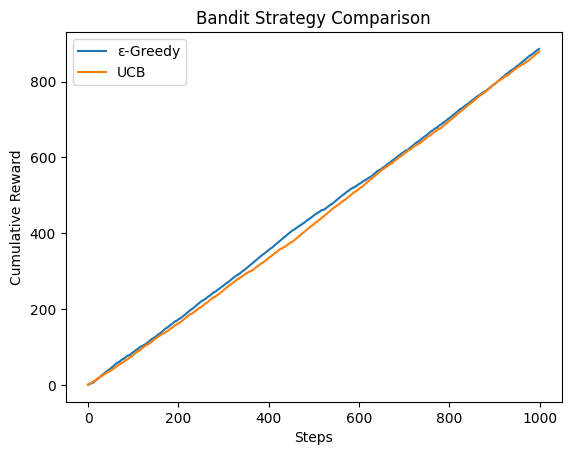

In [109]:
import matplotlib.pyplot as plt

plt.plot(rewards_eg, label="ε-Greedy")
plt.plot(rewards_ucb, label="UCB")
plt.xlabel("Steps")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.title("Bandit Strategy Comparison")
plt.show()

In [119]:
# Exercise 3: CartPole Q-Learning (Fixed using gymnasium)
import gymnasium as gym
import numpy as np

env = gym.make("CartPole-v1")

# Discretization
bins = [10, 10, 10, 10]

def discretize(state):
    upper = env.observation_space.high
    lower = env.observation_space.low
    
    # Fix infinite bounds
    upper[1] = 5
    upper[3] = 5
    lower[1] = -5
    lower[3] = -5
    
    ratios = (state - lower) / (upper - lower)
    ratios = np.clip(ratios, 0, 1)
    
    return tuple((ratios * (np.array(bins) - 1)).astype(int))

# Q-table
Q = {}

alpha = 0.1
gamma = 0.9
epsilon = 0.1
episodes = 200

rewards = []

for ep in range(episodes):
    state, _ = env.reset()
    state = discretize(state)
    
    total_reward = 0
    
    for _ in range(200):
        # ε-greedy
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = max([0,1], key=lambda a: Q.get((state,a),0))
        
        next_state, reward, done, truncated, _ = env.step(action)
        done = done or truncated
        
        next_state = discretize(next_state)
        
        old = Q.get((state, action), 0)
        future = max([Q.get((next_state, a), 0) for a in [0,1]])
        
        Q[(state, action)] = old + alpha * (reward + gamma * future - old)
        
        state = next_state
        total_reward += reward
        
        if done:
            break
    
    rewards.append(total_reward)

# Example output
print("First 10 episode rewards:", rewards[:10])
print("Last 10 episode rewards:", rewards[-10:])

ModuleNotFoundError: No module named 'gymnasium'

In [113]:
# Exercise 4: Traffic Signal

import numpy as np
import random

lanes = 2
actions = [0,1]  # which lane gets green

Q = {}
alpha = 0.1
gamma = 0.9
epsilon = 0.2

def get_reward(state):
    return -sum(state)

def next_state(state, action):
    state = list(state)
    
    # cars arrive
    state = [s + np.random.randint(0,3) for s in state]
    
    # green lane clears cars
    state[action] = max(0, state[action] - 2)
    
    return tuple(state)

# Training
for _ in range(200):
    state = (5,5)
    
    for _ in range(50):
        if random.random() < epsilon:
            action = random.choice(actions)
        else:
            action = max(actions, key=lambda a: Q.get((state,a),0))
        
        new_state = next_state(state, action)
        r = get_reward(new_state)
        
        old = Q.get((state,action),0)
        future = max([Q.get((new_state,a),0) for a in actions])
        
        Q[(state,action)] = old + alpha*(r + gamma*future - old)
        state = new_state

# Example run
state = (5,5)
for _ in range(10):
    action = max(actions, key=lambda a: Q.get((state,a),0))
    state = next_state(state, action)
    print("State:", state)

State: (5, 4)
State: (4, 4)
State: (4, 5)
State: (5, 4)
State: (4, 4)
State: (4, 6)
State: (4, 8)
State: (2, 9)
State: (1, 9)
State: (0, 9)


In [115]:
# Exercise 5: Bayesian Diagnosis

def bayes(P_D, P_S_given_D, P_S_given_not_D):
    P_not_D = 1 - P_D
    
    P_S = (P_S_given_D * P_D) + (P_S_given_not_D * P_not_D)
    
    P_D_given_S = (P_S_given_D * P_D) / P_S
    return P_D_given_S

# Example
P_D = 0.01
P_S_given_D = 0.9
P_S_given_not_D = 0.1

result = bayes(P_D, P_S_given_D, P_S_given_not_D)

print("Probability of disease given symptom:", result)

# Classification
threshold = 0.5
if result > threshold:
    print("Disease Present")
else:
    print("Disease Not Present")

Probability of disease given symptom: 0.08333333333333333
Disease Not Present
